# Topic 4 — Active Portfolio Management: a market-neutral long-short strategy

**Pipeline.** Every step uses only information available at the formation date.

1. **Data**: CRSP monthly returns (`monthly_returns.csv`, crsp.msf_v2), `MktRf.csv`, Compustat from WRDS
2. **GICS sectors**, point in time
3. **Universe**: the 500 largest liquid US common stocks each month, with a rank buffer to limit churn
4. **Benchmarks**: market, value-weighted and equal-weighted universe portfolios
5. **Characteristics**: risk exposures (beta, size, residual volatility) and alpha signals
6. **Risk model** (Barra style): monthly cross-sectional regressions → factor returns → $V = XFX^\top + D$
7. **Spearman IC** of each characteristic, month by month
8. **Alpha** $= \text{IC} \times \text{residual vol} \times z$ (Grinold), one signal at a time
9. **Portfolio**: monthly max-Sharpe dollar-neutral portfolio with Gurobi, factor exposures within ±margin
10. **Are the signals systematic?** Risk-forecast test of each signal's tilt
11. **Each signal alone** under three ways of handling its risk
12. **Transaction costs**: turnover penalty in the objective
13. **Covariance estimation**: shrinkage and sectors
14. Summary and next steps

**Timing convention.** A *formation date* $d$ is a month-end. Everything used to build the portfolio is
known at $d$; the portfolio is held over month $d+1$. `ret_next` always means the return of month $d+1$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import statsmodels.api as sm
import gurobipy as gp
from gurobipy import GRB

from IPython.display import display

import wrds_data

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 4)

# ---- parameters ---------------------------------------------------------------------------
WRDS_USERNAME = None      # your WRDS username (None -> prompted); only needed on the first run
N_STOCKS = 500            # universe size
BUFFER = 50               # an incumbent stays in the universe while its cap rank <= N_STOCKS + BUFFER
MIN_PRICE = 5.0           # $ price filter at the formation date
WINDOW = 60               # rolling estimation window in months (T in the project pdf)
MIN_OBS = 24              # minimum monthly returns to estimate a stock's beta / residual vol
TEST_START, TEST_END = "1995-01-31", "2025-12-31"    # out-of-sample holding months

ALPHA_SIGNALS = ["mom", "rev", "gp", "ag"]   # Momentum, Reversal, Asset growth, 
INFO_SIGNALS = ["bm", "ep"]                  # book-to-market and earnings-to-price
IC_PRIOR = 0.02           # IC in alpha = IC x residual vol x z (only matters relative to trading costs)

TARGET_VOL = 0.06         # ex-ante annual volatility of the long-short book (sets leverage only)
MARGIN_STYLE = 0.10       # |portfolio exposure| to a neutralized style factor (cross-sectional std units)
MARGIN_SECTOR = 0.02      # |net weight| in each GICS sector (fraction of capital)
W_MAX = 0.02              # max |weight| of one stock
GROSS_MAX = 4.0           # cap on sum |w| (long + short)
COST_BPS = 10             # one-way transaction cost in bp per unit of turnover

## 1. Data

`wrds_data.load` reads the CRSP export `monthly_returns.csv` (or pulls the same table from WRDS if the
file is absent), and pulls the CRSP–Compustat link, GICS sector history and Compustat annual
fundamentals. Everything is cached in `./data`, so WRDS is only queried on the first run.

Returns are pivoted to *date × permno* matrices. `MktRf.csv` is in **percent**, CRSP in decimals.

In [2]:
data = wrds_data.load(username=WRDS_USERNAME)

crsp = data["crsp"]
crsp = crsp[crsp.usincflg == "Y"].copy()                  # US-incorporated common stocks
crsp["date"] = crsp.mthcaldt + pd.offsets.MonthEnd(0)     # align to calendar month-end

RET = crsp.pivot(index="date", columns="permno", values="mthret")
CAP = crsp.pivot(index="date", columns="permno", values="mthcap")    # market cap in $000
PRC = crsp.pivot(index="date", columns="permno", values="mthprc")
dates = RET.index

mkt = pd.read_csv("MktRf.csv", index_col=0)
mkt.index = pd.to_datetime(mkt.index.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
mkt = (mkt / 100).rename(columns={"Mkt-RF": "mkt_rf", "RF": "rf"}).reindex(dates)   # percent -> decimal
RF, MKT_EX = mkt["rf"], mkt["mkt_rf"]
RET_EX = RET.sub(RF, axis=0)                               # excess returns

print(f"CRSP: {RET.shape[1]:,} US common stocks, {dates[0]:%Y-%m} to {dates[-1]:%Y-%m}")
print("months with missing market / rf data:", mkt.isna().any(axis=1).sum())

CRSP: 19,333 US common stocks, 1989-12 to 2025-12
months with missing market / rf data: 0


## 2. GICS sectors (point in time)

CRSP `permno` → Compustat `gvkey` through the CCM link valid at each date, then the GICS sector valid
at that date from `comp.co_hgic`. The history starts in 1999-06, so earlier months use each firm's
first recorded sector (a standard backfill; sectors rarely change). Firms missing from the history
use their current sector. Real Estate (created in 2016) is merged into Financials so every sector
exists over the whole sample.

In [3]:
for n, p in data.items():
    print("Name: ", n)
    print(p.head())

Name:  crsp
   permno   mthcaldt  mthret  mthprc     mthcap  siccd ticker usincflg
0   10001 1989-12-29  0.0380 10.1250 10347.7500   4920   GFGC        Y
1   10001 1990-01-31 -0.0185  9.9375 10156.1300   4920   GFGC        Y
2   10001 1990-02-28 -0.0063  9.8750 10092.2500   4920   GFGC        Y
3   10001 1990-03-30  0.0128  9.8750 10141.6300   4920   GFGC        Y
4   10001 1990-04-30  0.0000  9.8750 10141.6300   4920   GFGC        Y
Name:  ccm_links
    gvkey     permno     linkdt  linkenddt
0  001000 25881.0000 1970-11-13 1978-06-30
1  001001 10015.0000 1983-09-20 1986-07-31
2  001002 10023.0000 1972-12-14 1973-06-05
3  001003 10031.0000 1983-12-07 1989-08-16
4  001004 54594.0000 1972-04-24        NaT
Name:  gics_hist
    gvkey    indfrom    indthru gsector
0  001004 1999-06-30        NaT      20
1  001010 1999-06-30 2003-11-14      20
2  001013 1999-06-30 2010-12-12      45
3  001019 2021-05-07 2021-12-16      20
4  001021 1999-06-30 2014-09-15      35
Name:  gics_current
    gvkey 

In [4]:
SECTOR_NAMES = {10: "Energy", 15: "Materials", 20: "Industrials", 25: "Cons. Discretionary",
                30: "Cons. Staples", 35: "Health Care", 40: "Financials & RE", 45: "Info. Technology",
                50: "Communication", 55: "Utilities"}
SECTOR_CODES = sorted(SECTOR_NAMES)


def link_gvkey(keys, links):
    """(permno, date) rows -> gvkey of the CCM link valid at that date."""
    links = links.assign(linkenddt=links.linkenddt.fillna(pd.Timestamp("2099-12-31")))
    m = keys.merge(links, on="permno")
    m = m[(m.date >= m.linkdt) & (m.date <= m.linkenddt)] 
    return m.drop_duplicates(["permno", "date"])[["permno", "date", "gvkey"]]


keys = link_gvkey(crsp[["permno", "date"]], data["ccm_links"])
hist = data["gics_hist"].dropna(subset=["gsector"]).sort_values("indfrom")
sec = pd.merge_asof(keys.sort_values("date"), hist[["gvkey", "indfrom", "gsector"]],
                    left_on="date", right_on="indfrom", by="gvkey", direction="backward")
first_sector = hist.groupby("gvkey").gsector.first()
current_sector = data["gics_current"].set_index("gvkey").gsector
sec["gsector"] = sec.gsector.fillna(sec.gvkey.map(first_sector)).fillna(sec.gvkey.map(current_sector))
sec["sector"] = sec.gsector.astype(float).replace(60, 40)
SECTOR = sec.pivot(index="date", columns="permno", values="sector").reindex(index=dates, columns=RET.columns)

## 3. Point-in-time universe of 500 stocks

At each formation date $d$ a stock is **eligible** if it has a market cap, a price ≥ \$5, at least
`MIN_OBS` monthly returns in the last `WINDOW` months (so beta and volatility can be estimated) and a
GICS sector. Eligible stocks are ranked by market cap at $d$:

* incumbents stay while their rank is ≤ 550 (`N_STOCKS + BUFFER`),
* the remaining slots are filled with the largest non-members, so the universe always has 500 names.

The buffer avoids trading stocks in and out every time they cross rank 500.

In [5]:
NOBS = RET.notna().rolling(WINDOW, min_periods=1).sum()          # months of returns in the window
ELIG = (CAP > 0) & (PRC >= MIN_PRICE) & (NOBS >= MIN_OBS) & SECTOR.notna()
first_formation = ELIG.index[ELIG.sum(axis=1) >= N_STOCKS][0]

members, prev = {}, []
for d in dates[dates >= first_formation]:
    rank = CAP.loc[d][ELIG.loc[d]].rank(ascending=False)
    stay = rank.reindex(prev).dropna()
    stay = stay[stay <= N_STOCKS + BUFFER].nsmallest(N_STOCKS)      # incumbents inside the buffer
    new = rank.drop(stay.index).nsmallest(N_STOCKS - len(stay))      # fill with the largest non-members
    prev = list(stay.index) + list(new.index)
    members[d] = prev

UNIV = pd.DataFrame(False, index=dates, columns=RET.columns)
for d, p in members.items():
    UNIV.loc[d, p] = True

form_dates = list(members)
churn = pd.Series({d: len(set(members[d]) - set(members[p])) for p, d in zip(form_dates[:-1], form_dates[1:])})
cap_share = CAP.where(UNIV).sum(axis=1) / CAP.sum(axis=1)
smallest = CAP.where(UNIV).min(axis=1) / 1e6
print(f"first formation date: {first_formation:%Y-%m}, stocks per month: {UNIV.sum(axis=1)[form_dates].unique()}")
print(f"names entering per month: {churn.mean():.1f} on average")
print(f"share of total US common-stock market cap: {cap_share[form_dates].mean():.1%}")
print("smallest member ($bn):", smallest[["1995-12-31", "2005-12-31", "2015-12-31", "2025-11-30"]].round(2).to_dict())

first formation date: 1991-11, stocks per month: [500]
names entering per month: 5.5 on average
share of total US common-stock market cap: 79.8%
smallest member ($bn): {Timestamp('1995-12-31 00:00:00'): 1.94, Timestamp('2005-12-31 00:00:00'): 3.95, Timestamp('2015-12-31 00:00:00'): 6.04, Timestamp('2025-11-30 00:00:00'): 12.1}


## 4. Benchmarks

Before building anything, the performance to beat. Portfolios are formed at $d$ and held over $d+1$:

* **Market**: `Mkt-RF + RF` from `MktRf.csv` (Kenneth French's value-weighted market)
* **VW universe**: cap-weighted portfolio of the 500 stocks (weights = caps at $d$)
* **EW universe**: equally-weighted portfolio of the 500 stocks

A missing return in the holding month (rare) counts as 0. Sharpe ratios use excess returns over RF.
Alpha and beta come from a CAPM regression on the market excess return.

,Market,VW universe,EW universe
Ann. return,0.1187,0.1193,0.1200
Ann. excess return,0.0950,0.0957,0.0964
Ann. volatility,0.1556,0.1498,0.1601
Sharpe ratio,0.6110,0.6384,0.6019
Max drawdown,-0.5031,-0.4985,-0.5338
Beta (vs market),1.0000,0.9564,1.0017
Alpha (ann.),NaN,0.0048,0.0012
Alpha t-stat,NaN,1.4640,0.1720
Months,372.0000,372.0000,372.0000


,1995-2004,2005-2014,2015-2025
Sharpe ratio,,,
Market,0.5471,0.5024,0.7641
VW universe,0.5814,0.4991,0.8106
EW universe,0.6611,0.5208,0.6205


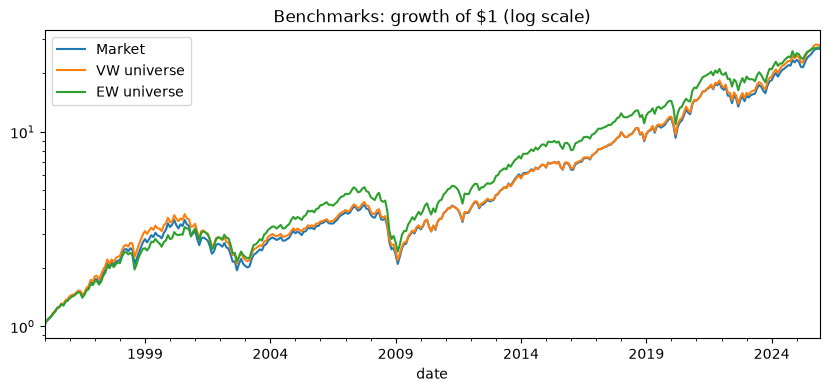

In [6]:
def hold(weights):
    """Monthly returns of portfolios formed at d (rows of `weights`) and held over month d+1."""
    return (weights.shift(1) * RET.fillna(0)).sum(axis=1, min_count=1)


def perf_table(excess):
    """Annualized performance of monthly excess returns (one column per strategy)."""
    out = {}
    for name, x in excess.items():
        x = x.dropna()
        total = x + RF.loc[x.index]
        wealth = (1 + total).cumprod()
        capm = sm.OLS(x, sm.add_constant(MKT_EX.loc[x.index])).fit()
        is_market = np.allclose(x, MKT_EX.loc[x.index])        # CAPM alpha of the market itself is 0 by construction
        out[name] = {"Ann. return": total.mean() * 12,
                     "Ann. excess return": x.mean() * 12,
                     "Ann. volatility": x.std() * np.sqrt(12),
                     "Sharpe ratio": x.mean() / x.std() * np.sqrt(12),
                     "Max drawdown": (wealth / wealth.cummax() - 1).min(),
                     "Beta (vs market)": capm.params.iloc[1],
                     "Alpha (ann.)": np.nan if is_market else capm.params.iloc[0] * 12,
                     "Alpha t-stat": np.nan if is_market else capm.tvalues.iloc[0],
                     "Months": len(x)}
    return pd.DataFrame(out)


PERIODS = {"1995-2004": ("1995", "2004"), "2005-2014": ("2005", "2014"), "2015-2025": ("2015", "2025")}


def sharpe_by_period(excess):
    return pd.DataFrame({p: excess.loc[a:b].mean() / excess.loc[a:b].std() * np.sqrt(12)
                         for p, (a, b) in PERIODS.items()})


W_VW = CAP.where(UNIV)
W_VW = W_VW.div(W_VW.sum(axis=1), axis=0)
W_EW = UNIV.astype(float).where(UNIV)
W_EW = W_EW.div(W_EW.sum(axis=1), axis=0)

bench = pd.DataFrame({"Market": MKT_EX,
                      "VW universe": hold(W_VW) - RF,
                      "EW universe": hold(W_EW) - RF}).loc[TEST_START:TEST_END]
display(perf_table(bench))
display(sharpe_by_period(bench).rename_axis("Sharpe ratio"))

fig, ax = plt.subplots()
(1 + bench.add(RF.loc[bench.index], axis=0)).cumprod().plot(ax=ax, logy=True)
ax.set_title("Benchmarks: growth of $1 (log scale)")
plt.show()

## 5. Characteristics

**Risk exposures** (the factors we control):
* **beta**: OLS slope of the stock's daily excess return on the daily market excess return
  (Fama-French `mktrf`) over the last 252 trading days up to $d$ (at least 126)
* **size**: log market cap at $d$
* **resvol**: standard deviation of the daily residuals of the same regression, × √21 (monthly units)

With 60 monthly returns a beta has a standard error of about 0.15–0.25; one year of daily returns
(≈ 252 observations) is much more precise and more responsive, which is what Barra does. The monthly
versions (60 months, at least 24) are kept as `beta_m`, `resvol_m` for comparison (section 6).

**Alpha signals**, oriented so that *higher = expected to outperform*:
* **mom**: return from $d-11$ to $d-1$ (12-1 momentum, skipping the last month)
* **rev**: minus the return of month $d$ (short-term reversal)
* **gp**: gross profits / total assets (profitability) &nbsp;&nbsp; **ag**: minus asset growth (investment)
* value, for the IC table only: **bm** = book equity / market cap, **ep** = earnings / market cap

Compustat numbers are used only 6 months after the fiscal year-end (when the 10-K is public) and
ignored once older than 18 months.

In [7]:
def rolling_beta_resvol(R_ex, m_ex, window, min_obs):
    """Rolling market-model beta and residual vol, stock by stock, with missing months handled."""
    valid = R_ex.notna().astype(float)
    y = R_ex.fillna(0.0)
    x = valid.mul(m_ex, axis=0)                  # market return only in months where the stock has data
    s = lambda A: A.rolling(window, min_periods=1).sum()
    n, sx, sy, sxx, sxy, syy = s(valid), s(x), s(y), s(x * x), s(x * y), s(y * y)
    cov = sxy - sx * sy / n
    var_x = sxx - sx ** 2 / n
    var_y = syy - sy ** 2 / n
    beta = cov / var_x
    res_var = (var_y - beta * cov) / (n - 2)
    ok = n >= min_obs
    return beta.where(ok), np.sqrt(res_var.clip(lower=0)).where(ok)


def daily_beta_resvol(R_ex, m_ex, month_ends, window=252, min_obs=126):
    """Beta and residual vol (monthly units) from the last `window` trading days up to each month-end."""
    Y_all, m_all = R_ex.to_numpy(), m_ex.to_numpy()[:, None]
    ends = R_ex.index.searchsorted(month_ends, side="right")     # one past the last trading day <= d
    betas, vols = {}, {}
    with np.errstate(invalid="ignore", divide="ignore"):
        for d, e in zip(month_ends, ends):
            Y, m = Y_all[max(0, e - window):e], m_all[max(0, e - window):e]
            valid = ~np.isnan(Y)
            n = valid.sum(axis=0)
            y, x = np.where(valid, Y, 0.0), np.where(valid, m, 0.0)
            sx, sy = x.sum(axis=0), y.sum(axis=0)
            cov = (x * y).sum(axis=0) - sx * sy / n
            var_x = (x * x).sum(axis=0) - sx ** 2 / n
            var_y = (y * y).sum(axis=0) - sy ** 2 / n
            beta = cov / var_x
            res_var = (var_y - beta * cov) / (n - 2)
            betas[d] = np.where(n >= min_obs, beta, np.nan)
            vols[d] = np.where(n >= min_obs, np.sqrt(np.clip(res_var, 0, None) * 21), np.nan)
    return pd.DataFrame(betas, index=R_ex.columns).T, pd.DataFrame(vols, index=R_ex.columns).T


cols = UNIV.columns[UNIV.any()]                   # stocks that are in the universe at least once
BETA_M, RESVOL_M = rolling_beta_resvol(RET_EX[cols], MKT_EX, WINDOW, MIN_OBS)

daily, ff_d = wrds_data.load_daily(cols, username=WRDS_USERNAME)   # ~9M rows, cached after the first run
ff_d = ff_d.set_index("date").astype(float)
DRET = daily.pivot(index="date", columns="permno", values="ret").astype(float).reindex(columns=cols)
DRET_EX = DRET.sub(ff_d.rf.reindex(DRET.index), axis=0)
BETA_D, RESVOL_D = daily_beta_resvol(DRET_EX, ff_d.mktrf.reindex(DRET.index), dates)
print(f"daily returns: {DRET.shape[0]:,} days x {DRET.shape[1]:,} stocks")

logret = np.log1p(RET[cols])
chars = {"beta": BETA_D.fillna(BETA_M),         # daily estimate, monthly one if too few daily returns
         "resvol": RESVOL_D.fillna(RESVOL_M),
         "beta_m": BETA_M,
         "resvol_m": RESVOL_M,
         "size": np.log(CAP[cols]),
         "mom": np.expm1(logret.shift(1).rolling(11, min_periods=9).sum()),
         "rev": -RET[cols],
         "sector": SECTOR[cols],
         "cap": CAP[cols],
         "ret_next": RET_EX[cols].shift(-1)}      # excess return of month d+1 (evaluation only)

idx = UNIV[cols].stack()
idx = idx[idx].index.set_names(["date", "permno"])      # (formation date, permno) of universe members
panel = pd.DataFrame({name: M.stack(future_stack=True).reindex(idx) for name, M in chars.items()})

# ---- Compustat annual fundamentals -------------------------------------------------------
fa = data["funda"].sort_values(["gvkey", "datadate"]).copy()
num = fa.columns.drop(["gvkey", "datadate"])
fa[num] = fa[num].astype(float)                           # nullable Float64 from WRDS -> plain float
preferred = fa.pstkrv.fillna(fa.pstkl).fillna(fa.pstk).fillna(0)
fa["be"] = fa.seq.fillna(fa.ceq + fa.pstk.fillna(0)).fillna(fa["at"] - fa["lt"]) + fa.txditc.fillna(0) - preferred
gap_days = (fa.datadate - fa.groupby("gvkey").datadate.shift(1)).dt.days
fa["at_lag"] = fa.groupby("gvkey")["at"].shift(1).where(gap_days < 400)       # previous fiscal year only
fa["gp"] = (fa.revt - fa.cogs) / fa["at"]
fa["ag"] = -(fa["at"] / fa.at_lag - 1)
fa["avail"] = fa.datadate + pd.offsets.MonthEnd(6)       # public 6 months after fiscal year-end

pk = link_gvkey(panel.index.to_frame(index=False), data["ccm_links"])
fund = pd.merge_asof(pk.sort_values("date"),
                     fa[["gvkey", "avail", "datadate", "be", "ib", "gp", "ag"]].sort_values("avail"),
                     left_on="date", right_on="avail", by="gvkey", direction="backward")
fund = fund[(fund.date - fund.datadate).dt.days <= 548]
panel = panel.join(fund.set_index(["date", "permno"])[["be", "ib", "gp", "ag"]])
panel["bm"] = panel.be.where(panel.be > 0) / (panel.cap / 1000)      # book equity in $M, cap in $000
panel["ep"] = panel.ib / (panel.cap / 1000)

STYLES = ["beta", "size", "resvol"]
SIGNALS = ALPHA_SIGNALS + INFO_SIGNALS
print("coverage (share of universe rows with data):")
print(panel[STYLES + SIGNALS].notna().mean().round(3).to_dict())
beta_pair = panel[["beta", "beta_m"]].dropna()
print(f"daily vs monthly beta: correlation {beta_pair.corr().iloc[0, 1]:.2f}, "
      f"avg cross-sectional std {panel.groupby(level='date').beta.std().mean():.2f} (daily) vs "
      f"{panel.groupby(level='date').beta_m.std().mean():.2f} (monthly)")

daily returns: 9,087 days x 1,751 stocks


coverage (share of universe rows with data):
{'beta': 1.0, 'size': 1.0, 'resvol': 1.0, 'mom': 1.0, 'rev': 1.0, 'gp': 0.999, 'ag': 0.998, 'bm': 0.975, 'ep': 0.999}
daily vs monthly beta: correlation 0.67, avg cross-sectional std 0.45 (daily) vs 0.58 (monthly)


### Standardization

Each characteristic gets two standardized versions:
* `x_...` **risk-factor exposure** (Barra convention): winsorize at ±3 std, then cap-weighted mean 0 and
  unit cross-sectional std, so the cap-weighted universe has zero exposure to every style factor.
* `z_...` **alpha score**: winsorize at ±3 std, z-score, then demean within each sector (a stock is
  compared with its sector peers, as the portfolio is sector-neutral anyway). Missing → 0.

In [8]:
def standardize(df, col, cap_weighted):
    def one_date(g):
        x = g[col]
        mu, sd = x.mean(), x.std()
        x = x.clip(mu - 3 * sd, mu + 3 * sd)
        w = g.cap.where(x.notna()) if cap_weighted else x.notna().astype(float)
        return (x - (x * w).sum() / w.sum()) / x.std()
    return df.groupby(level="date", group_keys=False)[[col, "cap"]].apply(one_date)


date_level = panel.index.get_level_values("date")
for c in STYLES + ["beta_m", "resvol_m"] + ALPHA_SIGNALS:
    panel["x_" + c] = standardize(panel, c, cap_weighted=True).fillna(0)
for c in SIGNALS:
    z = standardize(panel, c, cap_weighted=False)
    z = z - z.groupby([date_level, panel.sector]).transform("mean")
    panel["z_" + c] = (z / z.groupby(level="date").transform("std")).fillna(0)

display(panel.loc[panel.index[-1][0]].sort_values("cap", ascending=False).head(5)[
    ["sector", "beta", "size", "resvol", "x_beta", "x_size", "x_resvol", "z_mom", "z_gp"]])

,sector,beta,size,resvol,x_beta,x_size,x_resvol,z_mom,z_gp
permno,,,,,,,,,
86580,45.0000,1.8852,22.2346,0.0971,1.4508,1.3262,0.5483,0.1908,3.3113
14593,45.0000,1.2460,22.1138,0.0629,0.3125,1.3262,-0.4750,-0.3814,1.0425
10107,45.0000,0.8770,22.0027,0.0501,-0.3448,1.3262,-0.8581,-0.2170,-0.0198
84788,25.0000,1.3478,21.6265,0.0648,0.4938,1.3262,-0.4194,-0.1560,0.6231
90319,50.0000,1.0455,21.3227,0.0728,-0.0445,1.3262,-0.1785,1.2223,1.6098


## 6. Risk model: Barra-style cross-sectional regressions

For each formation date $d$ we regress the excess returns of month $d+1$ on the exposures known at $d$
(weighted least squares with weights $\sqrt{\text{cap}}$, the Barra convention):

$$ r_{i,d+1} = \sum_{s} \mathbb{1}\{i \in s\}\, f^{\text{sector}}_{s,d+1} + \sum_{k \in \text{styles}} x_{ik,d}\, f_{k,d+1} + u_{i,d+1} $$

The sector dummies sum to one, so they play the role of the market intercept (without sectors, a single
"Market" intercept replaces them). The **base model** has styles beta, size, resvol. Later we also fit an
**aware model** that adds the alpha signals as style factors.

Risk model at formation date $d$, from the last `WINDOW` months of realized factor returns and residuals:
* $F_d$ = sample covariance of factor returns, optionally shrunk toward its diagonal:
  $(1-\delta_F) F + \delta_F\, \mathrm{Diag}(F)$
* $D_d$ = diagonal of each stock's residual variance over the last 60 months (≥ 12 residuals, otherwise the
  daily residual variance), optionally with the log volatilities shrunk by $\delta_D$ toward their
  cross-sectional mean (the rule of the project pdf uses $\delta_D = 1/3$), or replaced by the daily
  residual variance of the last 252 days (more responsive)
* $V_d = X_d F_d X_d^\top + D_d$ (never formed explicitly; the optimizer uses the factor form)

average cross-sectional R^2: 0.216


,Energy,Materials,Industrials,Cons. Discretionary,Cons. Staples,Health Care,Financials & RE,Info. Technology,Communication,Utilities,beta,size,resvol
Ann. mean,0.0904,0.0841,0.1013,0.0932,0.0843,0.1099,0.0809,0.1453,0.0633,0.0722,0.0127,-0.0043,-0.0110
Ann. vol,0.2435,0.1972,0.1729,0.1772,0.1551,0.1590,0.1792,0.1888,0.1977,0.1779,0.0798,0.0248,0.0474
t-stat,2.0660,2.3737,3.2643,2.9266,3.0276,3.8501,2.5137,4.2860,1.7838,2.2593,0.8844,-0.9711,-1.2863


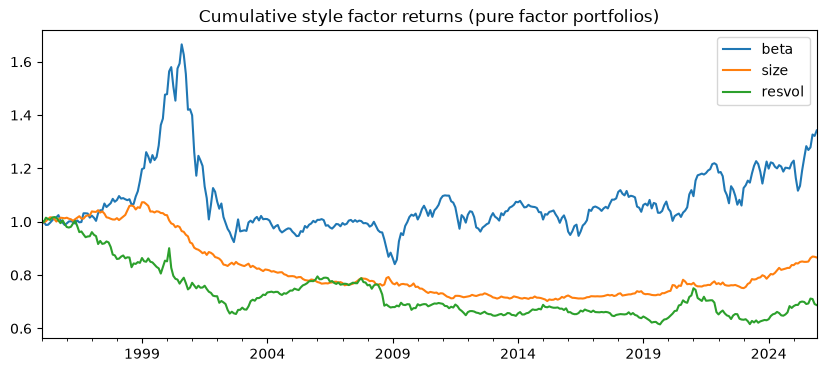

In [9]:
def exposures(df, use_sectors, styles):
    """Factor exposure matrix X (stocks x factors) at one formation date."""
    if use_sectors:
        base = (df.sector.to_numpy()[:, None] == np.array(SECTOR_CODES)[None, :]).astype(float)
    else:
        base = np.ones((len(df), 1))
    return np.hstack([base, df[["x_" + s for s in styles]].to_numpy()])


def factor_names(use_sectors, styles):
    return ([SECTOR_NAMES[s] for s in SECTOR_CODES] if use_sectors else ["Market"]) + list(styles)


def fit_risk_model(use_sectors=True, styles=STYLES):
    """Monthly WLS cross-sectional regressions. Factor returns and residuals are indexed by the month
    they are realized (d+1), so at formation date d everything up to index d is known."""
    f_rows, resid, r2 = {}, {}, {}
    for d, df in panel.groupby(level="date"):
        df = df.droplevel("date").dropna(subset=["ret_next"])
        if len(df) < 100:
            continue
        X, y, w = exposures(df, use_sectors, styles), df.ret_next.to_numpy(), np.sqrt(df.cap.to_numpy())
        present = X.any(axis=0)
        f = np.zeros(X.shape[1])
        sw = np.sqrt(w)[:, None]
        f[present] = np.linalg.lstsq(X[:, present] * sw, y * sw[:, 0], rcond=None)[0]
        u = y - X @ f
        t = d + pd.offsets.MonthEnd(1)
        f_rows[t] = f
        resid[t] = pd.Series(u, index=df.index)
        r2[t] = 1 - (w * u ** 2).sum() / (w * (y - np.average(y, weights=w)) ** 2).sum()
    resid = pd.DataFrame(resid).T
    return {"use_sectors": use_sectors, "styles": list(styles),
            "f_ret": pd.DataFrame(f_rows, index=factor_names(use_sectors, styles)).T,
            "resid": resid, "spec_var": resid.rolling(WINDOW, min_periods=12).var(), "r2": pd.Series(r2)}


def risk_at(model, d, df, f_shrink=0.0, spec_shrink=0.0, spec_daily=False):
    """X, F, D for the stocks of `df` (universe at formation date d), estimated with data up to d.
    spec_daily=True uses the daily residual vol (last 252 days) as specific risk instead of the
    variance of the monthly factor-model residuals."""
    X = exposures(df, model["use_sectors"], model["styles"])
    F = model["f_ret"].loc[:d].tail(WINDOW).cov().to_numpy()
    F = (1 - f_shrink) * F + f_shrink * np.diag(np.diag(F))
    sv = model["spec_var"]
    D = (sv.loc[d].reindex(df.index) if d in sv.index else pd.Series(np.nan, index=df.index))
    D = (df.resvol ** 2 if spec_daily else D.fillna(df.resvol ** 2)).to_numpy()
    if spec_shrink > 0:
        log_sd = 0.5 * np.log(D)
        D = np.exp(2 * ((1 - spec_shrink) * log_sd + spec_shrink * log_sd.mean()))
    return X, F, D


BASE = fit_risk_model(True, STYLES)
f = BASE["f_ret"].loc[TEST_START:TEST_END]
print(f"average cross-sectional R^2: {BASE['r2'].loc[TEST_START:].mean():.3f}")
display(pd.DataFrame({"Ann. mean": f.mean() * 12, "Ann. vol": f.std() * np.sqrt(12),
                      "t-stat": f.mean() / f.std() * np.sqrt(len(f))}).T)
(1 + f[STYLES]).cumprod().plot(title="Cumulative style factor returns (pure factor portfolios)")
plt.show()

### Daily or monthly exposures? Do sectors belong in the model (10 sectors ≈ 50 stocks each)?

Three models: the base model (daily beta / resvol, sectors), the same with **monthly** beta / resvol,
and the base model **without sectors**. Two checks:
* **Explained variance**: average weighted cross-sectional $R^2$.
* **Bias statistic**: for a test portfolio $h$ formed at $d$, $b = r_{h,d+1} / \hat\sigma_{h,d}$ with
  $\hat\sigma^2_{h,d} = h^\top V_d h$. If the model forecasts risk well, $b$ has std ≈ 1 (a band of about
  ±$\sqrt{2/T}$ ≈ ±0.07 for $T = 372$ months). Above 1 = risk underestimated. Test portfolios: the VW
  universe, 20 random dollar-neutral portfolios per month, and random *sector-tilted* dollar-neutral
  portfolios (long one random sector, short another).

In [10]:
test_forms = [d for d in form_dates if pd.Timestamp(TEST_START) <= d + pd.offsets.MonthEnd(1) <= pd.Timestamp(TEST_END)]


def bias_stats(model, tilts=(), n_random=20, seed=0, f_shrink=0.0, spec_shrink=0.0):
    """Std of realized return / predicted vol for several families of test portfolios."""
    rng = np.random.default_rng(seed)
    out = {"VW universe": [], "random long-short": [], "sector long-short": [], **{f"{c} tilt": [] for c in tilts}}
    for d in test_forms:
        df = panel.loc[d]
        X, F, D = risk_at(model, d, df, f_shrink, spec_shrink)
        r = df.ret_next.fillna(0).to_numpy()
        H = [("VW universe", (df.cap / df.cap.sum()).to_numpy())]
        for c in tilts:
            H.append((f"{c} tilt", df["z_" + c].to_numpy() - df["z_" + c].mean()))
        for _ in range(n_random):
            h = rng.standard_normal(len(df))
            H.append(("random long-short", h - h.mean()))
            a, b = rng.choice(SECTOR_CODES, 2, replace=False)
            H.append(("sector long-short", (df.sector == a).to_numpy() / (df.sector == a).sum()
                      - (df.sector == b).to_numpy() / (df.sector == b).sum()))
        for name, h in H:
            y = X.T @ h
            out[name].append((h @ r) / np.sqrt(y @ F @ y + h @ (D * h)))
    return pd.Series({k: np.std(v) for k, v in out.items() if v})


MODELS = {"base (daily exposures)": BASE,
          "monthly beta / resvol": fit_risk_model(True, ["beta_m", "size", "resvol_m"]),
          "no sectors": fit_risk_model(False, STYLES)}
display(pd.DataFrame({name: pd.concat([pd.Series({"avg R^2": m["r2"].loc[TEST_START:].mean()}), bias_stats(m)])
                      for name, m in MODELS.items()}).rename_axis("bias std (1 = accurate)"))

,base (daily exposures),monthly beta / resvol,no sectors
bias std (1 = accurate),,,
avg R^2,0.2155,0.2088,0.1096
VW universe,1.1336,1.1336,1.1311
random long-short,0.9964,0.9959,1.0013
sector long-short,1.0273,1.0284,2.0033


## 7. Monthly Spearman IC

For each formation date $d$: rank correlation between a characteristic at $d$ and the return of month $d+1$
across the 500 stocks.
* **raw IC**: against the excess return
* **residual IC**: against the residual $u_{i,d+1}$ of the base risk model. This is what a portfolio
  neutral to beta, size, residual vol and sectors can capture.

t-stat = mean / std × √months; IC IR = mean / std × √12.

Raw IC (vs next-month excess return)


,mean IC,IC std,t-stat,IC IR (ann.),% months > 0,mean 1995-2004,mean 2005-2014,mean 2015-2025
beta,0.0065,0.2676,0.4713,0.0847,0.5161,-0.0009,-0.0011,0.0208
size,-0.0016,0.0953,-0.3181,-0.0571,0.5081,-0.0035,-0.0097,0.0074
resvol,-0.0071,0.2059,-0.6655,-0.1195,0.5027,-0.0126,0.0011,-0.0085
mom,0.0120,0.1460,1.5834,0.2844,0.5806,0.0224,0.0169,-0.0012
rev,0.0146,0.1131,2.4852,0.4463,0.5376,0.0414,0.0011,0.0012
gp,0.0071,0.0784,1.7477,0.3139,0.5484,0.0106,0.0000,0.0103
ag,0.0038,0.0728,1.0069,0.1808,0.5054,0.0083,-0.0004,0.0031
bm,0.0038,0.1109,0.6598,0.1185,0.5081,0.0115,-0.0015,0.0009
ep,0.0113,0.1104,1.9821,0.3560,0.5403,0.0260,0.0015,0.0071


Residual IC (vs next-month risk-model residual)


,mean IC,IC std,t-stat,IC IR (ann.),% months > 0,mean 1995-2004,mean 2005-2014,mean 2015-2025
beta,-0.0076,0.0477,-3.0575,-0.5491,0.4301,-0.0051,-0.0013,-0.0163
size,0.0042,0.0496,1.6325,0.2932,0.5188,0.0068,0.0087,-0.0023
resvol,-0.0100,0.0529,-3.6608,-0.6575,0.4328,-0.0009,-0.0093,-0.0194
mom,0.0132,0.1308,1.9396,0.3484,0.5753,0.0207,0.0161,0.0047
rev,0.0195,0.1044,3.5987,0.6464,0.5833,0.0468,0.0054,0.0060
gp,0.0088,0.0832,2.0446,0.3672,0.5403,0.0136,0.0004,0.0123
ag,0.0036,0.0712,0.9725,0.1747,0.5242,0.0089,0.0010,0.0010
bm,-0.0024,0.1140,-0.4036,-0.0725,0.4785,0.0046,-0.0092,-0.0035
ep,0.0081,0.1086,1.4313,0.2571,0.5242,0.0214,-0.0010,0.0041


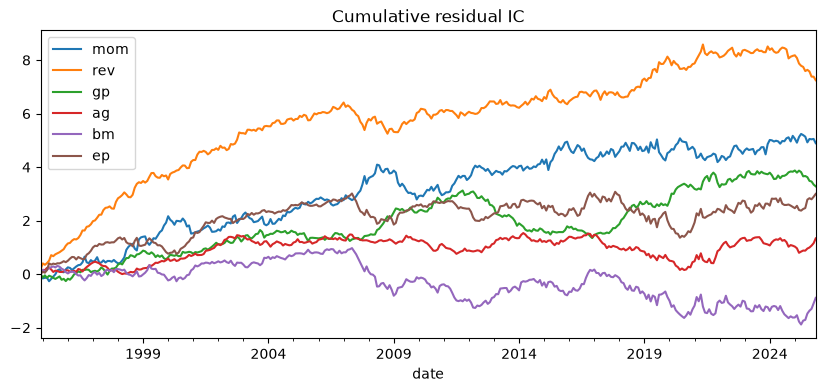

Average cross-sectional Spearman correlation between signals


,z_mom,z_rev,z_gp,z_ag,z_bm,z_ep
z_ag,-0.0200,-0.0100,-0.0300,1.0000,0.1800,0.0700
z_bm,-0.2600,0.0800,-0.3800,0.1800,1.0000,0.3500
z_ep,-0.2600,0.0800,0.0600,0.0700,0.3500,1.0000
z_gp,0.0100,-0.0000,1.0000,-0.0300,-0.3800,0.0600
z_mom,1.0000,-0.0000,0.0100,-0.0200,-0.2600,-0.2600
z_rev,-0.0000,1.0000,-0.0000,-0.0100,0.0800,0.0800


In [11]:
panel["resid_next"] = BASE["resid"].shift(-1).reindex(index=dates).stack(future_stack=True).reindex(panel.index)


def spearman_ic(col, target):
    x = panel[[col, target]].dropna()
    ranks = x.groupby(level="date").rank()
    return ranks.groupby(level="date").apply(lambda g: g[col].corr(g[target]))


ic_cols = {**{c: "x_" + c for c in STYLES}, **{c: "z_" + c for c in SIGNALS}}
IC_RAW = pd.DataFrame({c: spearman_ic(v, "ret_next") for c, v in ic_cols.items()})
IC_RES = pd.DataFrame({c: spearman_ic(v, "resid_next") for c, v in ic_cols.items()})


def ic_summary(ic):
    ic = ic.loc[test_forms[0]:test_forms[-1]]
    out = pd.DataFrame({"mean IC": ic.mean(), "IC std": ic.std(),
                        "t-stat": ic.mean() / ic.std() * np.sqrt(len(ic)),
                        "IC IR (ann.)": ic.mean() / ic.std() * np.sqrt(12),
                        "% months > 0": (ic > 0).mean()})
    for p, (a, b) in PERIODS.items():
        out[f"mean {p}"] = ic.loc[a:b].mean()
    return out


print("Raw IC (vs next-month excess return)")
display(ic_summary(IC_RAW))
print("Residual IC (vs next-month risk-model residual)")
display(ic_summary(IC_RES))

IC_RES[SIGNALS].loc[test_forms[0]:].cumsum().plot(title="Cumulative residual IC")
plt.show()
print("Average cross-sectional Spearman correlation between signals")
display(panel[["z_" + c for c in SIGNALS]].groupby(level="date").corr(method="spearman").groupby(level=1).mean().round(2))

## 8. From a signal to an alpha

Grinold's rule turns a score into an expected residual return:

$$ \alpha_{i,d} = \text{IC} \times \sigma_{i,d} \times z_{i,d} $$

where $\sigma_{i,d}$ is the stock's residual (specific) volatility from the base risk model at $d$ and
$z$ the signal's score. Stocks with more idiosyncratic risk get proportionally larger alphas, so for a
given score the alpha-to-risk ratio is the same across stocks. A few universe members have extreme
return histories (CRSP has monthly returns above +1000% for some meme/SPAC stocks), so for the alpha
only, $\log \sigma$ is winsorized at ±3 std across stocks each month; the risk model keeps the raw value.

Each signal is first tested **on its own** with the same prior `IC_PRIOR` = 0.02. For the optimizer
at a fixed risk budget the IC only rescales alpha and does not change the portfolio; it matters only
relative to the turnover penalty (section 12). Combining signals comes after we have seen them alone.

In [12]:
sv = BASE["spec_var"].reindex(index=dates).stack(future_stack=True).reindex(panel.index)
log_sd = 0.5 * np.log(sv.fillna(panel.resvol ** 2))
mu, sd = log_sd.groupby(level="date").transform("mean"), log_sd.groupby(level="date").transform("std")
panel["spec_vol"] = np.exp(log_sd.clip(mu - 3 * sd, mu + 3 * sd))
for c in ALPHA_SIGNALS:
    panel["alpha_" + c] = IC_PRIOR * panel.spec_vol * panel["z_" + c]
display(panel[["alpha_" + c for c in ALPHA_SIGNALS]].describe().T[["mean", "std", "min", "max"]] * 1e4)
print("(monthly alpha in basis points)")

,mean,std,min,max
alpha_mom,1.0064,21.7090,-192.1468,384.1185
alpha_rev,-0.1602,19.7045,-799.2280,243.7315
alpha_gp,-0.2962,17.4422,-296.4574,133.9319
alpha_ag,-1.0467,20.6988,-509.8649,180.8176


(monthly alpha in basis points)


## 9. Portfolio construction with Gurobi

The Sharpe ratio of a dollar-neutral portfolio, $\alpha^\top w / \sqrt{w^\top V w}$, does not depend on the
scale of $w$. We fix the scale with a risk budget and maximize expected return net of a turnover penalty:

$$ \max_w\ \alpha^\top w - \kappa \sum_i |w_i - w_i^{\text{prev}}| \quad \text{s.t.}\quad
   w^\top (XFX^\top + D) w \le \sigma^2_{\text{target}},\quad \mathbf{1}^\top w = 0,\quad
   |X_k^\top w| \le m_k,\quad |w_i| \le w_{\max},\quad \textstyle\sum_i |w_i| \le G $$

With only the budget and $\mathbf 1^\top w = 0$ (and $\kappa = 0$) the solution is exactly the max-Sharpe
(tangency) direction $V^{-1}(\alpha - c\mathbf 1)$; the other constraints give the best Sharpe achievable at
that risk level.
* factor exposures $y = X^\top w$ are auxiliary variables, so the risk is $y^\top F y + \sum_i D_i w_i^2$:
  a sparse quadratic constraint instead of a dense 500×500 matrix
* sectors: net weight (long − short) within ±`MARGIN_SECTOR`
* style factors listed as *neutral*: exposure within ±`MARGIN_STYLE` (std units; since $\mathbf 1^\top w = 0$,
  a beta exposure of 0.1 is a portfolio beta of about 0.1 × std(beta) ≈ 0.04). Other style factors are free.
  Beta, size and resvol are always neutral.
* $\kappa$ = `tc_penalty` × `COST_BPS`: the optimizer only trades when the alpha gained beats the cost

Accounting: the book is dollar-neutral, so its monthly excess return is $w^\top r_{d+1}$ (the cash
collateral earns RF). Turnover $= \sum_i |w_{i,d} - w_{i,d-1}|$ (names leaving the universe are sold),
charged `COST_BPS` per unit.

In [13]:
env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()


def max_sharpe_long_short(alpha, X, F, D, margins, w_prev, kappa):
    n, k = X.shape
    with gp.Model(env=env) as m:
        w = m.addMVar(n, lb=-W_MAX, ub=W_MAX, name="w")
        y = m.addMVar(k, lb=-margins, ub=margins, name="y")      # factor exposures within ±margin
        a = m.addMVar(n, lb=0.0, name="abs_w")                   # a_i >= |w_i|
        m.addConstr(X.T @ w == y)
        m.addConstr(w.sum() == 0)
        m.addConstr(a >= w)
        m.addConstr(a >= -w)
        m.addConstr(a.sum() <= GROSS_MAX)
        m.addConstr(y @ F @ y + w @ sp.diags(D) @ w <= TARGET_VOL ** 2 / 12)
        objective = alpha @ w
        if kappa > 0:
            t = m.addMVar(n, lb=0.0, name="trade")               # t_i >= |w_i - w_prev_i|
            m.addConstr(t >= w - w_prev)
            m.addConstr(t >= w_prev - w)
            objective = objective - kappa * t.sum()
        m.setObjective(objective, GRB.MAXIMIZE)
        m.optimize()
        return w.X


def backtest(signal, model, neutral=(), tc_penalty=0.0, f_shrink=0.0, spec_shrink=0.0, spec_daily=False):
    """Monthly out-of-sample backtest of the max-Sharpe long-short book for one alpha signal."""
    names = factor_names(model["use_sectors"], model["styles"])
    neutral = set(STYLES) | set(neutral)
    margins = np.array([MARGIN_SECTOR if nm in SECTOR_NAMES.values() else
                        MARGIN_STYLE if nm in neutral else GRB.INFINITY for nm in names])
    if not model["use_sectors"]:
        margins[0] = GRB.INFINITY                     # market intercept exposure = sum(w) = 0 anyway
    kappa = tc_penalty * COST_BPS / 1e4
    w_prev, rows = pd.Series(dtype=float), []
    for d in test_forms:
        df = panel.loc[d]
        X, F, D = risk_at(model, d, df, f_shrink, spec_shrink, spec_daily)
        F = F + 1e-10 * np.eye(len(F))
        w = max_sharpe_long_short(df["alpha_" + signal].to_numpy(), X, F, D, margins,
                                  w_prev.reindex(df.index).fillna(0).to_numpy(), kappa)
        w = pd.Series(w, index=df.index)
        y = X.T @ w.to_numpy()
        rows.append({"date": d + pd.offsets.MonthEnd(1),
                     "gross": (w * df.ret_next.fillna(0)).sum(),
                     "turnover": w.sub(w_prev, fill_value=0).abs().sum(),
                     "ex_ante_vol": np.sqrt((y @ F @ y + w.to_numpy() ** 2 @ D) * 12),
                     "leverage": w.abs().sum()})
        w_prev = w
    bt = pd.DataFrame(rows).set_index("date")
    bt["net"] = bt.gross - COST_BPS / 1e4 * bt.turnover
    return bt


def summarize(bt):
    """One row of out-of-sample statistics for a backtest."""
    g, n = bt.gross, bt.net
    sharpe = lambda x: x.mean() / x.std() * np.sqrt(12)
    wealth = (1 + n + RF.loc[n.index]).cumprod()
    capm = sm.OLS(n, sm.add_constant(MKT_EX.loc[n.index])).fit()
    return pd.Series({"Sharpe gross": sharpe(g), "Sharpe net": sharpe(n),
                      "Ann. return net": n.mean() * 12, "Realized vol": g.std() * np.sqrt(12),
                      "Vol ratio (real./target)": g.std() * np.sqrt(12) / TARGET_VOL,
                      "Turnover / month": bt.turnover.mean(), "Leverage": bt.leverage.mean(),
                      "Max drawdown net": (wealth / wealth.cummax() - 1).min(),
                      "Beta": capm.params.iloc[1], "Alpha t-stat net": capm.tvalues.iloc[0]})

## 10. Are the alpha signals systematic?

If the stocks favored by a signal move *together*, a tilt on that signal is one big factor bet: it does
not diversify across 500 names, and a risk model without that factor treats the common movement as
idiosyncratic noise, so it **underestimates** the risk of the tilt.

Test: bias statistic of each signal's tilt portfolio ($h \propto z$) under
* the **base** model (sectors + beta, size, resvol)
* the **aware** model, which also includes the four alpha signals as style factors

The aware model also gives each signal's *pure factor return* (its cross-sectional regression coefficient),
the return of a portfolio with unit exposure to the signal and zero exposure to everything else.

In [14]:
AWARE = fit_risk_model(True, STYLES + ALPHA_SIGNALS)
fa_ret = AWARE["f_ret"].loc[TEST_START:TEST_END, ALPHA_SIGNALS]
systematic = pd.DataFrame({
    "bias std, base model": bias_stats(BASE, tilts=ALPHA_SIGNALS, n_random=0)[[f"{c} tilt" for c in ALPHA_SIGNALS]].to_numpy(),
    "bias std, aware model": bias_stats(AWARE, tilts=ALPHA_SIGNALS, n_random=0)[[f"{c} tilt" for c in ALPHA_SIGNALS]].to_numpy(),
    "pure factor ann. return": fa_ret.mean().to_numpy() * 12,
    "pure factor ann. vol": fa_ret.std().to_numpy() * np.sqrt(12),
    "pure factor Sharpe": (fa_ret.mean() / fa_ret.std() * np.sqrt(12)).to_numpy(),
}, index=ALPHA_SIGNALS)
display(systematic)
print(f"average cross-sectional R^2: base {BASE['r2'].loc[TEST_START:].mean():.3f}, aware {AWARE['r2'].loc[TEST_START:].mean():.3f}")

,"bias std, base model","bias std, aware model",pure factor ann. return,pure factor ann. vol,pure factor Sharpe
mom,2.1423,1.1349,0.0205,0.0490,0.4181
rev,1.8953,1.0623,0.0139,0.0360,0.3846
gp,1.5722,0.9256,0.0093,0.0286,0.3253
ag,1.2522,0.9175,0.0095,0.0201,0.4704


average cross-sectional R^2: base 0.216, aware 0.251


## 11. Each signal alone, three ways to handle its risk

| treatment | risk model | exposure to the alpha factors |
|---|---|---|
| **blind** | base (the alpha factors are not in the model) | unconstrained (the model cannot see it) |
| **aware, free** | aware | unconstrained, but its risk is now priced by $F$ |
| **aware, neutral** | aware | within ±`MARGIN_STYLE`: only the stock-specific part of the alpha is used |

No turnover penalty here (κ = 0); "net" charges `COST_BPS` per unit of turnover after the fact.

Sharpe gross  Sharpe net  Ann. return net  Realized vol  Vol ratio (real./target)  Turnover / month  Leverage  Max drawdown net  \
signal treatment                                                                                                                                         
mom    blind                 0.3439      0.2226           0.0402        0.1806                    3.0100            1.8236    3.7891           -0.5514   
       aware, free           0.5883      0.3116           0.0214        0.0685                    1.1423            1.5774    2.9601           -0.2897   
       aware, neutral        0.3091      0.0427           0.0035        0.0809                    1.3478            1.7956    3.7996           -0.2958   
rev    blind                 0.4079     -0.0815          -0.0115        0.1410                    2.3508            5.7538    3.8595           -0.7897   
       aware, free           0.0488     -0.5969          -0.0412        0.0691                    1.1515            3.7145    2.7291           -0.6749   
       aware, neutral       -0.8159     -1.6870          -0.1253        0.0743                    1.2387            5.3844    3.7947           -0.9612   
gp     blind                 0.3495      0.3098           0.0338        0.1092                    1.8200            0.3615    3.8347           -0.4105   
       aware, free           0.5938      0.4627           0.0294        0.0636                    1.0594            0.6972    2.5394           -0.3281   
       aware, neutral        0.1600      0.0426           0.0028        0.0657                    1.0949            0.6430    3.7283           -0.3020   
ag     blind                 0.2411      0.1490           0.0143        0.0960                    1.6001            0.7355    3.7497           -0.4551   
       aware, free           0.3296      0.1817           0.0110        0.0603                    1.0050            0.7417    2.6041           -0.3454   
       aware, neutral        0.1468     -0.0270          -0.0018        0.0658                    1.0968            0.9529    3.7671           -0.3585   

                         Beta  Alpha t-stat net  
signal treatment                                 
mom    blind          -0.2573            2.0097  
       aware, free     0.0069            1.6544  
       aware, neutral  0.0240            0.0793  
rev    blind           0.3052           -1.6685  
       aware, free     0.0494           -3.6637  
       aware, neutral -0.0160           -9.1302  
gp     blind          -0.1165            2.2834  
       aware, free    -0.0388            2.8645  
       aware, neutral -0.0282            0.4573  
ag     blind          -0.0335            0.9990  
       aware, free    -0.0374            1.3231  
       aware, neutral -0.0043           -0.1135

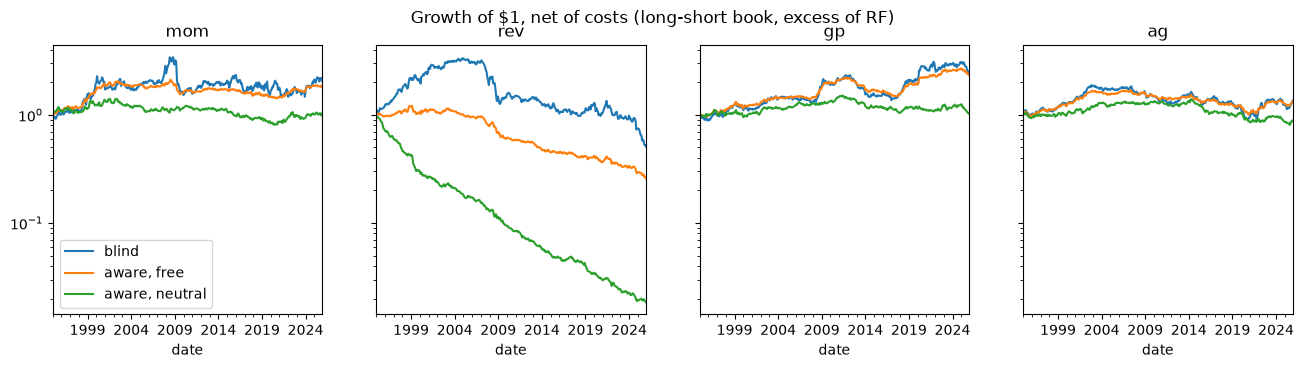

In [15]:
TREATMENTS = {"blind": (BASE, ()), "aware, free": (AWARE, ()), "aware, neutral": (AWARE, ALPHA_SIGNALS)}
bt_alone = {(c, t): backtest(c, model, neutral) for c in ALPHA_SIGNALS for t, (model, neutral) in TREATMENTS.items()}
table_alone = pd.DataFrame({k: summarize(v) for k, v in bt_alone.items()}).T
table_alone.index.names = ["signal", "treatment"]
display(table_alone)

fig, axes = plt.subplots(1, len(ALPHA_SIGNALS), figsize=(16, 3.5), sharey=True)
for ax, c in zip(axes, ALPHA_SIGNALS):
    for t in TREATMENTS:
        (1 + bt_alone[(c, t)].net).cumprod().plot(ax=ax, logy=True, label=t)
    ax.set_title(c)
axes[0].legend()
fig.suptitle("Growth of $1, net of costs (long-short book, excess of RF)")
plt.show()

## 12. Transaction costs: turnover penalty in the objective

Same backtests with $\kappa$ = `tc_penalty` × cost per unit of turnover, under the *aware, free* treatment.
With `tc_penalty` = 1 the optimizer charges itself the true cost of each trade; > 1 makes it trade even
less (useful when the alpha is overstated, since the realized ICs are below `IC_PRIOR`).

In [16]:
TC_GRID = [0.0, 1.0, 3.0]
bt_tc = {(c, k): (bt_alone[(c, "aware, free")] if k == 0 else backtest(c, AWARE, tc_penalty=k))
         for c in ALPHA_SIGNALS for k in TC_GRID}
table_tc = pd.DataFrame({k: summarize(v) for k, v in bt_tc.items()}).T
table_tc.index.names = ["signal", "tc_penalty"]
display(table_tc[["Sharpe gross", "Sharpe net", "Ann. return net", "Turnover / month", "Alpha t-stat net"]])

Sharpe gross  Sharpe net  Ann. return net  Turnover / month  Alpha t-stat net
signal tc_penalty                                                                               
mom    0.0000            0.5883      0.3116           0.0214            1.5774            1.6544
       1.0000            0.4660      0.4158           0.0270            0.2710            2.3844
       3.0000            0.2960      0.2735           0.0177            0.1208            1.5681
rev    0.0000            0.0488     -0.5969          -0.0412            3.7145           -3.6637
       1.0000            0.1815     -0.0186          -0.0012            1.0942           -0.7259
       3.0000           -0.0268     -0.1125          -0.0071            0.4481           -1.1802
gp     0.0000            0.5938      0.4627           0.0294            0.6972            2.8645
       1.0000            0.4982      0.4755           0.0283            0.1137            2.8245
       3.0000            0.3313      0.3193           0.0188            0.0590            2.1609
ag     0.0000            0.3296      0.1817           0.0110            0.7417            1.3231
       1.0000            0.4744      0.4383           0.0265            0.1817            2.4495
       3.0000            0.6596      0.6390           0.0387            0.1032            3.4209

## 13. Covariance estimation: shrinkage and sectors

Same strategies (*aware, free*, `tc_penalty` = 1) with different covariance estimators:
* **sample**: sample factor covariance over 60 months, raw specific variances (the default)
* **F → diagonal 50%**: factor covariance shrunk halfway toward its diagonal ($\delta_F = 0.5$)
* **specific 1/3**: log specific vols shrunk 1/3 toward their cross-sectional mean ($\delta_D = 1/3$)
* **both** shrinkages
* **specific: daily**: specific variance = daily residual variance of the last 252 days
* **no sectors**: aware model with a market intercept instead of the 10 sector factors

A better estimator should give a vol ratio (realized / target) closer to 1 and a higher Sharpe.

In [17]:
AWARE_NO_SECT = fit_risk_model(False, STYLES + ALPHA_SIGNALS)
COV_VARIANTS = {"sample": (AWARE, 0.0, 0.0, False), "F -> diagonal 50%": (AWARE, 0.5, 0.0, False),
                "specific 1/3": (AWARE, 0.0, 1 / 3, False), "both": (AWARE, 0.5, 1 / 3, False),
                "specific: daily": (AWARE, 0.0, 0.0, True), "no sectors": (AWARE_NO_SECT, 0.0, 0.0, False)}
bt_cov = {(c, v): (bt_tc[(c, 1.0)] if v == "sample" else
                   backtest(c, model, tc_penalty=1.0, f_shrink=fs, spec_shrink=ss, spec_daily=sd))
          for c in ALPHA_SIGNALS for v, (model, fs, ss, sd) in COV_VARIANTS.items()}
table_cov = pd.DataFrame({k: summarize(v) for k, v in bt_cov.items()}).T
table_cov.index.names = ["signal", "covariance"]
display(table_cov[["Sharpe gross", "Sharpe net", "Realized vol", "Vol ratio (real./target)", "Turnover / month"]])
display(table_cov["Sharpe net"].unstack().assign(average=lambda x: x.mean(axis=1)).T.round(3))

Sharpe gross  Sharpe net  Realized vol  Vol ratio (real./target)  Turnover / month
signal covariance                                                                                           
mom    sample                   0.4660      0.4158        0.0650                    1.0837            0.2710
       F -> diagonal 50%        0.4163      0.3768        0.0622                    1.0370            0.2039
       specific 1/3             0.3628      0.3110        0.0722                    1.2030            0.3102
       both                     0.2938      0.2537        0.0707                    1.1782            0.2357
       specific: daily          0.4641      0.4124        0.0616                    1.0267            0.2648
       no sectors               0.0250     -0.0192        0.0817                    1.3609            0.3006
rev    sample                   0.1815     -0.0186        0.0656                    1.0938            1.0942
       F -> diagonal 50%        0.0748     -0.1093        0.0635                    1.0583            0.9734
       specific 1/3             0.1587     -0.0373        0.0723                    1.2046            1.1804
       both                     0.0534     -0.1298        0.0689                    1.1489            1.0517
       specific: daily          0.1368     -0.0850        0.0587                    0.9778            1.0838
       no sectors               0.0226     -0.1665        0.0688                    1.1458            1.0830
gp     sample                   0.4982      0.4755        0.0596                    0.9939            0.1137
       F -> diagonal 50%        0.3901      0.3713        0.0574                    0.9569            0.0906
       specific 1/3             0.4870      0.4630        0.0666                    1.1096            0.1346
       both                     0.4038      0.3833        0.0634                    1.0567            0.1093
       specific: daily          0.5130      0.4889        0.0559                    0.9322            0.1128
       no sectors               0.1165      0.0964        0.0895                    1.4921            0.1508
ag     sample                   0.4744      0.4383        0.0605                    1.0078            0.1817
       F -> diagonal 50%        0.4507      0.4163        0.0582                    0.9707            0.1666
       specific 1/3             0.4620      0.4253        0.0669                    1.1156            0.2045
       both                     0.4318      0.3971        0.0652                    1.0864            0.1882
       specific: daily          0.3825      0.3432        0.0557                    0.9278            0.1809
       no sectors               0.4951      0.4615        0.0619                    1.0319            0.1725

signal,ag,gp,mom,rev
covariance,,,,
F -> diagonal 50%,0.4160,0.3710,0.3770,-0.1090
both,0.3970,0.3830,0.2540,-0.1300
no sectors,0.4610,0.0960,-0.0190,-0.1670
sample,0.4380,0.4750,0.4160,-0.0190
specific 1/3,0.4250,0.4630,0.3110,-0.0370
specific: daily,0.3430,0.4890,0.4120,-0.0850
average,0.4140,0.3800,0.2920,-0.0910


## 14. Preview: do the single-signal books diversify each other?

The signals' scores are almost uncorrelated (section 7), so their long-short books should be too. Before
building a proper combined alpha, a quick check on the books already computed (*aware, free*,
`tc_penalty` = 1): correlation of their monthly net returns, and the Sharpe of an equal-weight mix.
If $K$ books have similar Sharpe $S$ and are uncorrelated, the mix has Sharpe ≈ $S\sqrt{K}$.

In [18]:
books = pd.DataFrame({c: bt_tc[(c, 1.0)].net for c in ALPHA_SIGNALS})
display(books.corr().round(2))
mixes = {"mom + gp + ag": ["mom", "gp", "ag"], "all four": ALPHA_SIGNALS}
mix_ret = pd.DataFrame({name: books[m].mean(axis=1) for name, m in mixes.items()})
display(pd.concat([perf_table(books), perf_table(mix_ret), perf_table(bench[["Market"]])], axis=1)
        .loc[["Ann. excess return", "Ann. volatility", "Sharpe ratio", "Max drawdown", "Beta (vs market)", "Alpha t-stat"]])
display(sharpe_by_period(pd.concat([mix_ret, bench[["Market"]]], axis=1)).rename_axis("Sharpe ratio"))

,mom,rev,gp,ag
mom,1.0000,-0.1000,-0.0000,-0.0000
rev,-0.1000,1.0000,-0.0200,-0.0500
gp,-0.0000,-0.0200,1.0000,0.1400
ag,-0.0000,-0.0500,0.1400,1.0000


,mom,rev,gp,ag,mom + gp + ag,all four,Market
Ann. excess return,0.0270,-0.0012,0.0283,0.0265,0.0273,0.0202,0.0950
Ann. volatility,0.0651,0.0655,0.0596,0.0605,0.0371,0.0309,0.1556
Sharpe ratio,0.4158,-0.0186,0.4755,0.4383,0.7355,0.6521,0.6110
Max drawdown,-0.2009,-0.3280,-0.2323,-0.1827,-0.0551,-0.0786,-0.5031
Beta (vs market),-0.0133,0.0771,-0.0246,-0.0058,-0.0146,0.0083,1.0000
Alpha t-stat,2.3844,-0.7259,2.8245,2.4495,4.2397,3.4335,NaN


,1995-2004,2005-2014,2015-2025
Sharpe ratio,,,
mom + gp + ag,1.1075,0.4465,0.6226
all four,1.1303,0.1026,0.6569
Market,0.5471,0.5024,0.7641


## 15. Summary of the first full run

* **Universe and benchmarks.** 500 US stocks, about 80% of US market cap, 5.5 names replaced per month.
  1995–2025 Sharpe ratios: market 0.61, VW universe 0.64, EW universe 0.60.
* **Risk model.** Sectors are essential: without them the model underestimates sector risk by 2× and
  $R^2$ halves (0.22 → 0.11). Daily exposures raise $R^2$ only slightly over monthly ones.
* **The alpha signals are systematic.** The base model underestimates the risk of momentum, reversal,
  profitability and asset-growth tilts by 1.3–2.2×. With the signals added as factors (*aware* model), the
  forecasts become accurate (≈ 0.9–1.15) and realized volatility matches the target.
* **Handling that risk.** *Aware, free* gives the best Sharpe for every signal except reversal. *Neutral*
  (only the stock-specific part) destroys most of the alpha: in large caps the premium sits in the
  systematic component, so the task is to size it correctly, not to hedge it away.
* **Transaction costs.** The turnover penalty (κ = cost) cuts turnover 3–6× and raises net Sharpe (momentum and
  asset growth most). Reversal shows why costs matter: 4–6× turnover per month, and its net Sharpe is
  ≤ 0 whatever the risk treatment or penalty.
* **Covariance estimation.** With the right factors in the model, extra shrinkage (factor covariance
  toward its diagonal, specific vols toward their mean) *lowers* the Sharpe. The structure of the
  factor model is the regularization that matters; daily specific risk is mixed.

**Next steps:** build one combined alpha from momentum, profitability and asset growth, optimized
jointly rather than averaging books; sub-period and drawdown analysis of the final strategy; slides.